In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

base = '/content/drive/MyDrive/KemikAI/data/raw'
processed = '/content/drive/MyDrive/KemikAI/data/processed'

print("✅ Hazır!")

Mounted at /content/drive
✅ Hazır!


In [2]:

boneage_path = f'{base}/RSNA_Annotations/RSNA_Annotations/BONEAGE'
df = pd.read_csv(f'{boneage_path}/boneage_train.csv')

# Ay cinsinden yaşı yıla çevir
df['age_years'] = df['Boneage'] / 12
df['gender'] = df['Male'].apply(lambda x: 1 if x else 0)

print("Veri shape:", df.shape)
print("\nEksik değer var mı:")
print(df.isnull().sum())
print("\nİlk 5 satır:")
df.head()

Veri shape: (12611, 5)

Eksik değer var mı:
ID           0
Male         0
Boneage      0
age_years    0
gender       0
dtype: int64

İlk 5 satır:


,ID,Male,Boneage,age_years,gender
0,1377,False,180,15.000000,0
1,1378,False,12,1.000000,0
2,1379,False,94,7.833333,0
3,1380,True,120,10.000000,1
4,1381,False,82,6.833333,0


In [3]:
np.random.seed(42)
n = len(df)

# Cinsiyete göre gerçekçi boy/kilo üret
df['height_cm'] = np.where(
    df['gender'] == 1,
    np.random.normal(120 + df['age_years'] * 4.5, 5, n),
    np.random.normal(118 + df['age_years'] * 4.3, 5, n)
)
df['weight_kg'] = np.where(
    df['gender'] == 1,
    np.random.normal(20 + df['age_years'] * 3.2, 4, n),
    np.random.normal(19 + df['age_years'] * 3.0, 4, n)
)

# Anne/baba boyu
df['mother_height'] = np.random.normal(162, 6, n)
df['father_height'] = np.random.normal(174, 7, n)

# Hedef boy (Mid-parental height formülü)
df['target_height'] = np.where(
    df['gender'] == 1,
    (df['mother_height'] + df['father_height'] + 13) / 2,
    (df['mother_height'] + df['father_height'] - 13) / 2
)

# Beslenme verileri
df['vitamin_d'] = np.random.choice([0, 1], n, p=[0.3, 0.7])  # 0=eksik
df['calcium_level'] = np.random.choice([0, 1, 2], n, p=[0.2, 0.5, 0.3])  # 0=düşük
df['fracture_history'] = np.random.choice([0, 1], n, p=[0.85, 0.15])

print("✅ Sentetik klinik veri oluşturuldu!")
print(df.head())

✅ Sentetik klinik veri oluşturuldu!
     ID   Male  Boneage  age_years  gender   height_cm  weight_kg  \
0  1377  False      180  15.000000       0  190.844040  67.657385   
1  1378  False       12   1.000000       0  114.657060  19.818488   
2  1379  False       94   7.833333       0  159.469266  43.127992   
3  1380   True      120  10.000000       1  172.615149  52.469294   
4  1381  False       82   6.833333       0  149.828281  45.130665   

   mother_height  father_height  target_height  vitamin_d  calcium_level  \
0     163.226602     172.664772     161.445687          1              0   
1     157.588918     173.757788     159.173353          0              2   
2     166.659990     171.140542     162.400266          0              1   
3     161.720529     181.679474     178.200001          1              0   
4     167.033343     186.610835     170.322089          1              1   

   fracture_history  
0                 0  
1                 0  
2                 0  
3   

In [4]:
synthetic_path = '/content/drive/MyDrive/KemikAI/data/synthetic'
df.to_csv(f'{synthetic_path}/clinical_data.csv', index=False)
print("✅ Klinik veri kaydedildi!")
print(f"Toplam satır: {len(df)}")

✅ Klinik veri kaydedildi!
Toplam satır: 12611


Görüntü shape: (224, 224, 3)
Min: 0.0 Max: 1.0


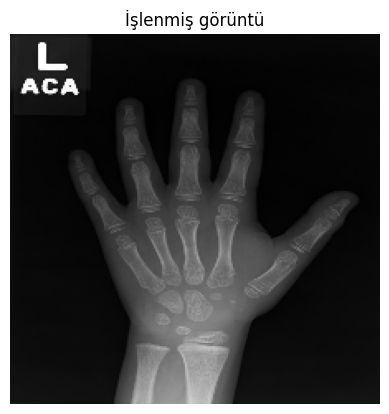

✅ Görüntü işleme fonksiyonu hazır!


In [5]:
from tensorflow.keras.preprocessing.image import img_to_array
import cv2

def goruntu_isle(img_path, hedef_boyut=(224, 224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, hedef_boyut)
    img = img / 255.0  # normalize
    img = np.stack([img]*3, axis=-1)  # RGB'ye çevir
    return img

# Test edelim
train_img_path = f'{base}/RSNA_train/images'
test_img = os.listdir(train_img_path)[0]
islenmis = goruntu_isle(f'{train_img_path}/{test_img}')

print("Görüntü shape:", islenmis.shape)
print("Min:", islenmis.min(), "Max:", islenmis.max())
plt.imshow(islenmis)
plt.title("İşlenmiş görüntü")
plt.axis('off')
plt.show()
print("✅ Görüntü işleme fonksiyonu hazır!")